In [1]:
import os, shutil
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from matplotlib import rc

# Use the paper LaTeX style when a TeX install is present; degrade gracefully otherwise.
_USETEX = shutil.which("latex") is not None
rc("text", usetex=_USETEX)
rc("font", **{"family": "sans-serif", "sans-serif": ["Helvetica"],
              "weight": "bold", "size": 16})
print("usetex =", _USETEX)

usetex = True


# Z4 PRS diagnostic matrix — does the symmetry actually break?

Companion to `Z4_prs_scan_analysis.ipynb`. The production PRS fat-wall scan showed the
wall-area observable $\mathcal{A}$ *rising monotonically* — which looked like an ever-growing
wall network but was diagnosed as an **artifact: the field never breaks the symmetry**, so
$\mathcal{A}$ is just phase-noise of a $\phi=0$ field amplified by the $a_I$ prefactor.

This notebook isolates the cause with a **2$\times$5 diagnostic matrix** at $N=256$,
$\mu=0.01$, $k_{\rm cut}=3$, $t_{\max}=90$ (so $a:1\to91$), at the two extreme breaking
strengths $\beta_4\in\{0.1,\,0.9\}$. The box (`lSide`) is the production value for each
$\beta_4$ and is held fixed across all five variants, so **only the EOM knobs differ**:

| variant  | `prsWall` | `prsDamping` | `prsStartA` | equation of motion |
|----------|:---------:|:------------:|:-----------:|--------------------|
| **v0std**  | false | 0   | 0  | standard: $\phi''+2\mathcal{H}\phi'-\nabla^2\phi-a^2\mu^2\phi=0$ |
| **v1damp** | false | 1.0 | 0  | $+$ extra Hubble drag ($2\mathcal{H}\to3\mathcal{H}$) |
| **v2wall** | true  | 0   | 0  | prsWall (drops the $a^2$ on $V'$ $\Rightarrow$ tachyon mass$^2$ frozen at $\mu^2$) |
| **v3both** | true  | 1.0 | 0  | prsWall $+$ damping — **the current (broken) production config** |
| **v4stag** | true  | 1.0 | 50 | **staged**: standard EOM until $a\ge50$, then full PRS |

**Predictions (from the mechanism analysis).** Near $\phi=0$ the instability is tachyonic,
$V''(0)=-\mu^2$. Standard EOM gives comoving tachyonic mass$^2=a^2\mu^2$ (grows $\propto a^2$),
which eventually beats friction and breaks the symmetry. `prsWall` drops the $a^2$, freezing
the tachyonic mass$^2$ at $\mu^2$ — the amplification that drives breaking is gone.

- **v0std, v1damp** $\to$ break the symmetry ($\mathrm{rms}\,\phi\to\mathcal{O}(1)$, $E_{V_1}<0$).
- **v2wall, v3both** $\to$ stay frozen at $\phi=0$ forever $\Rightarrow$ isolates `prsWall` as the culprit.
- **v4stag** $\to$ partial: starts breaking but the $a\ge50$ switch freezes a sub-grid wall.

> **PRS only maintains an *already-formed* network — it cannot take the field *through* the
> transition from $\phi=0$.** The clean fix is a vacuum-manifold random-phase initial condition
> (walls at $a=1$, PRS-from-$t_0$ to maintain them).

In [2]:
BASE = "/mt/user-batch/dpasari/scan_z4_prs_diag/"

MU         = 0.01
KCUTOFF    = 3
N_LAT      = 256
TMAX       = 90.0
PRS_START_A = 50.0          # staged-PRS switch (v4stag): full PRS once a >= this

BETA4_VALS = [0.1, 0.9]     # two extremes of the Z4-breaking strength

# variant key -> (legend label, colour, linestyle)
VARIANTS = [
    ("v0std",  "Standard EOM (control)",                "#000000", "-"),
    ("v1damp", r"$+$ damping ($3\mathcal{H}$)",          "#1f77b4", "-"),
    ("v2wall", "prsWall only",                           "#ff7f0e", "-"),
    ("v3both", r"prsWall $+$ damping (production)",       "#d62728", "-"),
    ("v4stag", r"staged PRS ($a\geq 50$)",               "#2ca02c", "-"),
]
VKEYS   = [v[0] for v in VARIANTS]
VLABEL  = {v[0]: v[1] for v in VARIANTS}
VCOLOR  = {v[0]: v[2] for v in VARIANTS}
VSTYLE  = {v[0]: v[3] for v in VARIANTS}

def float_str(x):
    return f"{x:g}".replace(".", "p")

def couplings_from_mu_beta4(mu, beta4):
    # V = -mu^2|Phi|^2 + lambda1|Phi|^4 - lambda2(Phi^4+Phi*^4), unit vev v=1
    assert 0.0 < beta4 < 1.0, beta4
    lambda1 = mu * mu / (1.0 - beta4)
    lambda2 = beta4 * mu * mu / (2.0 * (1.0 - beta4))
    return lambda1, lambda2

def result_dir(beta4, vkey):
    return f"{BASE}results_DWZ4_b4{float_str(beta4)}_{vkey}/"

# Wall widths (program units) from the static BVP in wall_width_box_calculator_Z4.ipynb.
DELTA_OPP = 1.40                                  # type-2 (diagonal), beta-independent
DELTA_ADJ = {0.1: 2.380, 0.9: 1.087}             # type-1 (adjacent)
def delta_min(b): return min(DELTA_ADJ[b], DELTA_OPP)   # thinnest wall -> sets resolution

V0 = MU * MU / 4.0   # +V at phi=0 in program units (= 2.5e-5); a real vacuum gives -V0

print(f"{'beta_4':>7s} {'lambda1':>12s} {'lambda2':>12s} {'d_adj':>6s} {'d_opp':>6s} {'d_min':>6s}")
for b in BETA4_VALS:
    l1, l2 = couplings_from_mu_beta4(MU, b)
    print(f"{b:7.2f} {l1:12.6e} {l2:12.6e} {DELTA_ADJ[b]:6.3f} {DELTA_OPP:6.3f} {delta_min(b):6.3f}")
print(f"\nV(phi=0) = +{V0:.3e}  (Ev_1 pinned here = frozen; Ev_1 < 0 = broken)")

 beta_4      lambda1      lambda2  d_adj  d_opp  d_min
   0.10 1.111111e-04 5.555556e-06  2.380  1.400  1.400
   0.90 1.000000e-03 4.500000e-04  1.087  1.400  1.087

V(phi=0) = +2.500e-05  (Ev_1 pinned here = frozen; Ev_1 < 0 = broken)


## Loader functions

In [3]:
def load_energies(path):
    """average_energies.txt: 9 fixed cols + 2 wall cols.
    t, Ek_1, Ek_2, Eg_1, Eg_2, Ev_1, Ev_2, Ev_3, E_tot, Scal_type_1, Scal_type_2"""
    fpath = os.path.join(path, "average_energies.txt")
    try:
        data = np.loadtxt(fpath)
    except (FileNotFoundError, OSError):
        print(f"[load_energies] NOT FOUND: {fpath}")
        return None
    if data.ndim == 1:
        data = data[np.newaxis, :]
    if data.shape[1] < 11:
        print(f"[load_energies] only {data.shape[1]} cols (wall cols missing?): {fpath}")
        return None
    return {
        "eta": data[:, 0],
        "Ek_1": data[:, 1], "Ek_2": data[:, 2],
        "Eg_1": data[:, 3], "Eg_2": data[:, 4],
        "Ev_1": data[:, 5], "Ev_2": data[:, 6], "Ev_3": data[:, 7],
        "E_tot": data[:, 8],
        "scal1": data[:, 9], "scal2": data[:, 10],
    }

def load_scalar(path, idx):
    fpath = os.path.join(path, f"average_scalar_{idx}.txt")
    try:
        data = np.loadtxt(fpath)
    except (FileNotFoundError, OSError):
        return None
    if data.ndim == 1:
        data = data[np.newaxis, :]
    return {"eta": data[:, 0], "phi": data[:, 1], "phi_prime": data[:, 2],
            "phi2": data[:, 3], "phi_prime2": data[:, 4],
            "rms_phi": data[:, 5], "rms_phi_p": data[:, 6]}

def load_scale_factor(path):
    fpath = os.path.join(path, "average_scale_factor.txt")
    try:
        data = np.loadtxt(fpath)
    except (FileNotFoundError, OSError):
        return None
    if data.ndim == 1:
        data = data[np.newaxis, :]
    return {"eta": data[:, 0], "a": data[:, 1], "aprime": data[:, 2], "H": data[:, 3]}

def load_lside(path):
    fpath = os.path.join(path, "DWZ4.infos")
    try:
        with open(fpath) as f:
            for line in f:
                p = line.split()
                if len(p) >= 2 and p[0] == "lSide":
                    return float(p[1])
    except (FileNotFoundError, OSError):
        return None
    return None

def eta_at_a(sf, a_target):
    """Conformal time at which a first reaches a_target (for marking the staged switch)."""
    if sf is None:
        return None
    a = sf["a"]
    hit = np.where(a >= a_target)[0]
    return sf["eta"][hit[0]] if len(hit) else None

def eta_break(en):
    """eta where Ev_1 first goes negative (symmetry-breaking onset); None if never."""
    if en is None:
        return None
    neg = np.where(en["Ev_1"] < 0)[0]
    return en["eta"][neg[0]] if len(neg) else None

## Load all runs  — `runs[beta4][vkey]`

In [4]:
runs = {b: {} for b in BETA4_VALS}

print(f"{'beta4':>6s} {'variant':>7s} {'lSide':>9s} {'dx':>7s} "
      f"{'rms_max':>8s} {'rms_end':>8s} {'Ev1_end':>11s} {'eta_break':>9s}  status")
print("-" * 86)
for b in BETA4_VALS:
    for vk in VKEYS:
        path = result_dir(b, vk)
        en = load_energies(path)
        sf = load_scale_factor(path)
        s0 = load_scalar(path, 0)
        s1 = load_scalar(path, 1)
        lside = load_lside(path)
        dx = (lside / N_LAT) if lside else np.nan
        ok = en is not None and sf is not None and s0 is not None
        runs[b][vk] = {
            "beta4": b, "vkey": vk, "label": VLABEL[vk],
            "color": VCOLOR[vk], "style": VSTYLE[vk], "lw": 2.6,
            "lside": lside, "dx": dx,
            "energies": en, "scale_factor": sf, "scalar_0": s0, "scalar_1": s1,
        }
        rmax = s0["rms_phi"].max() if s0 else np.nan
        rend = s0["rms_phi"][-1] if s0 else np.nan
        ev1  = en["Ev_1"][-1] if en else np.nan
        ebr  = eta_break(en)
        ebr_s = f"{ebr:.1f}" if ebr is not None else "  --"
        print(f"{b:6.2f} {vk:>7s} {str(lside):>9s} {dx:7.4f} "
              f"{rmax:8.4f} {rend:8.4f} {ev1:11.3e} {ebr_s:>9s}  {'OK' if ok else 'MISSING'}")

# eta of the staged-PRS switch (background is identical across variants)
ETA_SWITCH = {b: eta_at_a(runs[b]["v0std"]["scale_factor"], PRS_START_A) for b in BETA4_VALS}
print(f"\nstaged-PRS switch a={PRS_START_A:g} at eta = "
      + ", ".join(f"beta4={b}: {ETA_SWITCH[b]:.1f}" for b in BETA4_VALS))

 beta4 variant     lSide      dx  rms_max  rms_end     Ev1_end eta_break  status
--------------------------------------------------------------------------------------
  0.10   v0std     179.2  0.7000   0.8504   0.6900  -2.199e-05      52.7  OK
  0.10  v1damp     179.2  0.7000   0.7676   0.6643  -2.293e-05      50.1  OK
  0.10  v2wall     179.2  0.7000   0.0034   0.0000   2.500e-05        --  OK
  0.10  v3both     179.2  0.7000   0.0034   0.0000   2.500e-05        --  OK
  0.10  v4stag     179.2  0.7000   0.4149   0.2968   1.623e-05        --  OK
  0.90   v0std   139.136  0.5435   0.7497   0.6154  -1.609e-05      53.7  OK
  0.90  v1damp   139.136  0.5435   0.6727   0.5841  -2.156e-05      50.7  OK
  0.90  v2wall   139.136  0.5435   0.0034   0.0000   2.500e-05        --  OK
  0.90  v3both   139.136  0.5435   0.0034   0.0000   2.500e-05        --  OK
  0.90  v4stag   139.136  0.5435   0.3335   0.1932   1.898e-05        --  OK

staged-PRS switch a=50 at eta = beta4=0.1: 49.0, beta4=0.9: 4

## Plot helpers

In [5]:
def paper_ax(ax, xlabel=r"$\eta$", ylabel="", title=""):
    ax.set_xlabel(xlabel, fontsize=26)
    if ylabel: ax.set_ylabel(ylabel, fontsize=26)
    if title:  ax.set_title(title, fontsize=20)
    ax.xaxis.set_ticks_position("both"); ax.yaxis.set_ticks_position("both")
    ax.tick_params(axis="both", which="both", direction="in", labelsize=18, pad=8)
    ax.tick_params(which="major", length=9); ax.tick_params(which="minor", length=4)
    ax.minorticks_on()
    ax.grid(True, linestyle="--", linewidth=0.4, alpha=0.6)

def variant_handles(lw=3):
    return [Line2D([0], [0], color=VCOLOR[vk], lw=lw, ls=VSTYLE[vk], label=VLABEL[vk])
            for vk in VKEYS]

def mark_switch(ax, b):
    """Vertical guide at the staged-PRS switch (only v4stag flips here)."""
    es = ETA_SWITCH.get(b)
    if es is not None:
        ax.axvline(es, color=VCOLOR["v4stag"], lw=1.2, ls=":", alpha=0.8)

def area_param(d, en_key):
    """Wall-area parameter A = scal / (2 a H), length-aligned."""
    en, sf = d["energies"], d["scale_factor"]
    n = min(len(en["eta"]), len(sf["a"]))
    A = en[en_key][:n] / (2.0 * sf["a"][:n] * sf["H"][:n])
    return en["eta"][:n], A

## 1 &middot; Order parameter $\mathrm{rms}\,\phi$ — *does it break?*

The single clearest diagnostic. A broken vacuum sits on $|\Phi|=v=1$ so $\mathrm{rms}\,\phi$ rises
to $\mathcal{O}(1)$; a field frozen at the symmetric maximum stays at the tiny IC fluctuation
level ($\sim$`3e-3`) and decays. The dotted green line marks the staged-PRS switch ($a=50$).

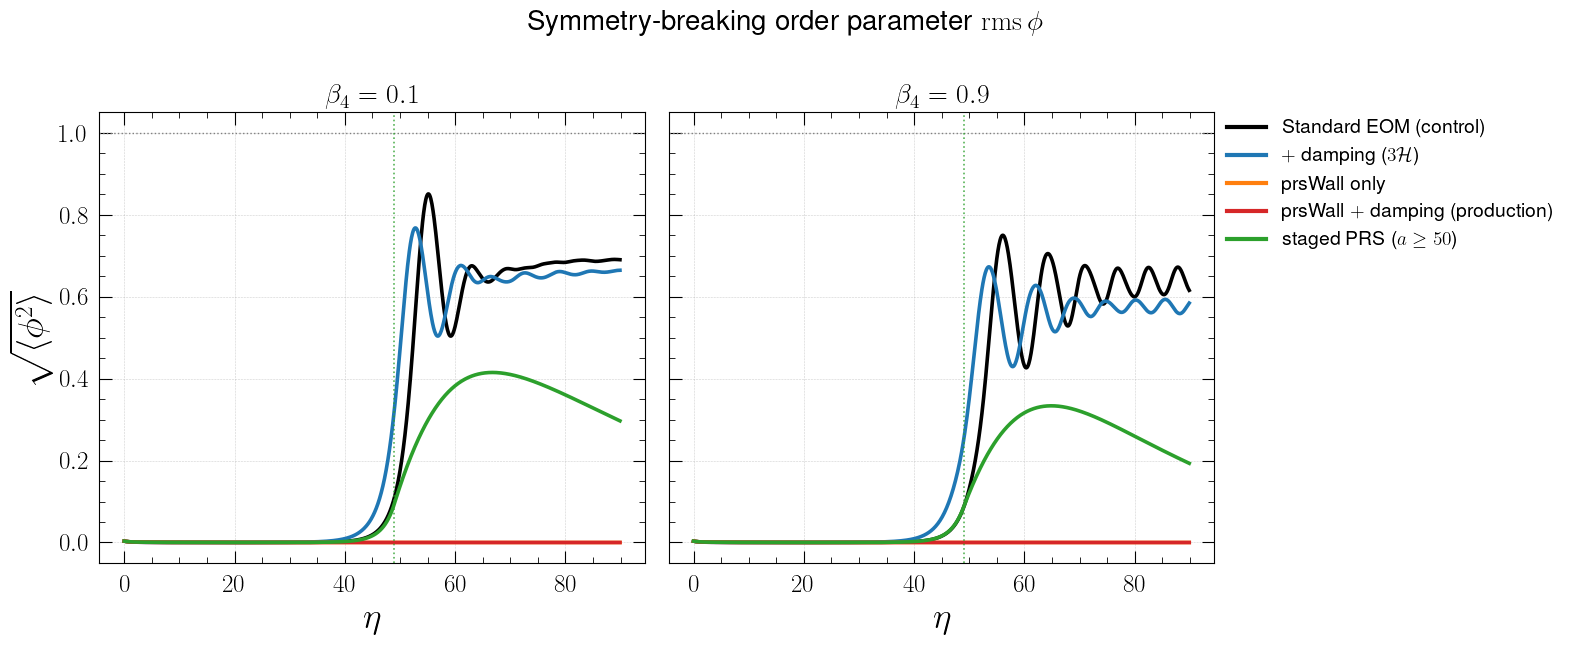

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6.5), sharey=True)
for ax, b in zip(axes, BETA4_VALS):
    for vk in VKEYS:
        d = runs[b][vk]; s0 = d["scalar_0"]
        if s0 is None: continue
        ax.plot(s0["eta"], s0["rms_phi"], color=d["color"], ls=d["style"], lw=d["lw"])
    ax.axhline(1.0, color="grey", lw=1, ls=":")   # vacuum |Phi| = v = 1
    mark_switch(ax, b)
    paper_ax(ax, ylabel=r"$\sqrt{\langle\phi^2\rangle}$" if b == BETA4_VALS[0] else "",
             title=rf"$\beta_4 = {b}$")
axes[1].legend(handles=variant_handles(), fontsize=14, frameon=False,
               loc="upper left", bbox_to_anchor=(1.01, 1), borderaxespad=0)
fig.suptitle(r"Symmetry-breaking order parameter $\mathrm{rms}\,\phi$", fontsize=20, y=1.0)
plt.tight_layout()
plt.savefig("Z4_prs_diag_rms.pdf", bbox_inches="tight")
plt.show()

## 2 &middot; Vacuum energy $E_{V_1}$ — the same story, energetically

$E_{V_1}$ is $+V_0=+2.5\times10^{-5}$ at $\phi=0$ and flips to $-V_0$ once the field reaches the
true vacuum. **Negative $\Rightarrow$ broken; pinned at $+V_0$ $\Rightarrow$ frozen.**

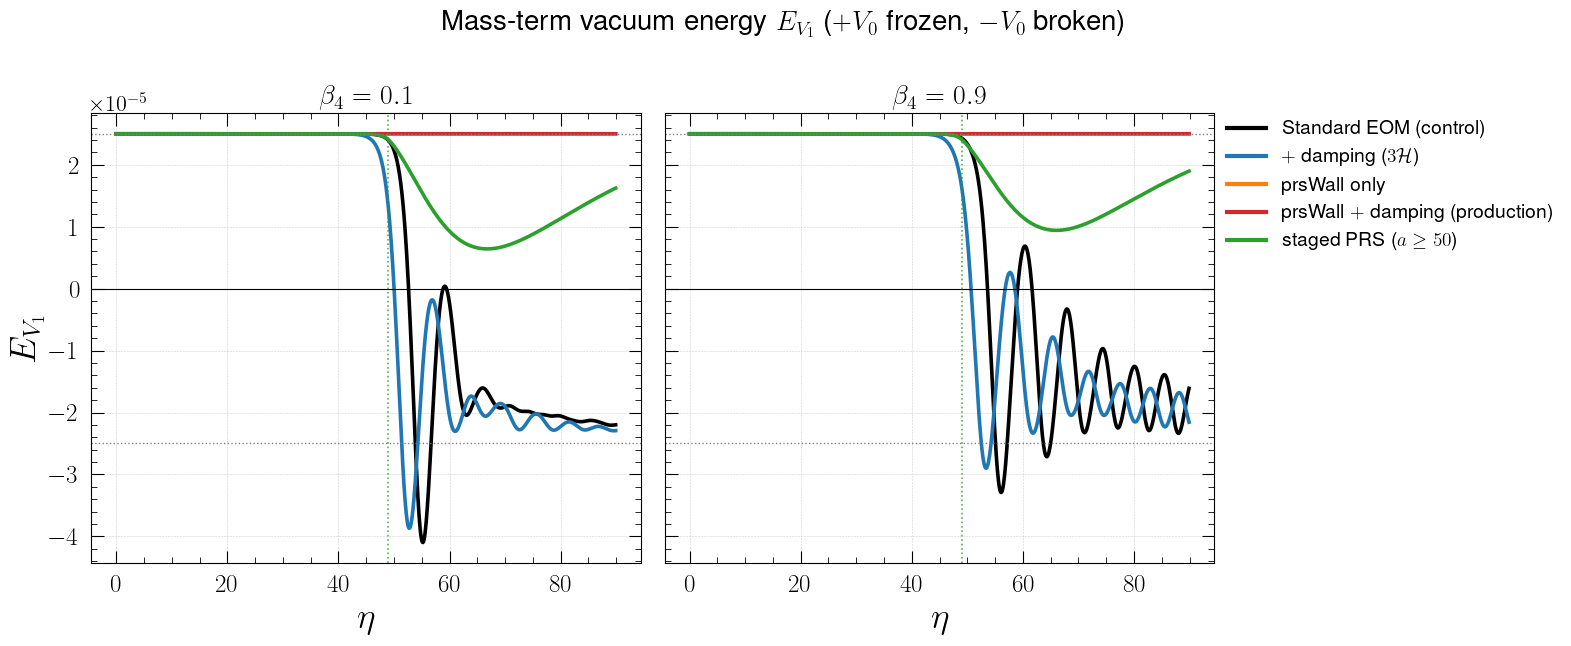

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6.5), sharey=True)
for ax, b in zip(axes, BETA4_VALS):
    for vk in VKEYS:
        d = runs[b][vk]; en = d["energies"]
        if en is None: continue
        ax.plot(en["eta"], en["Ev_1"], color=d["color"], ls=d["style"], lw=d["lw"])
    ax.axhline(+V0, color="grey", lw=1, ls=":")
    ax.axhline(-V0, color="grey", lw=1, ls=":")
    ax.axhline(0.0, color="k", lw=0.8)
    mark_switch(ax, b)
    paper_ax(ax, ylabel=r"$E_{V_1}$" if b == BETA4_VALS[0] else "", title=rf"$\beta_4 = {b}$")
axes[1].legend(handles=variant_handles(), fontsize=14, frameon=False,
               loc="upper left", bbox_to_anchor=(1.01, 1), borderaxespad=0)
fig.suptitle(r"Mass-term vacuum energy $E_{V_1}$  ($+V_0$ frozen, $-V_0$ broken)",
             fontsize=20, y=1.0)
plt.tight_layout()
plt.savefig("Z4_prs_diag_Ev1.pdf", bbox_inches="tight")
plt.show()

## 3 &middot; Wall-area observable $\mathcal{A}=\mathrm{scal}/(2aH)$ — noise vs. real walls

This is the production observable. For the **frozen** runs (v2wall, v3both) $|\Phi|\approx0$, so the
vacuum phase $\theta=\mathrm{atan2}(\phi_2,\phi_1)$ is *random per site* and `scal` counts noise
links $\times$ the $a_I$ prefactor $\Rightarrow$ a large, *rising* $\mathcal{A}$ — exactly the
"ever-growing wall area" mirage. For the **broken** runs $\mathcal{A}$ is orders of magnitude
smaller (real walls). Log scale; type-1 solid, type-2 dashed.

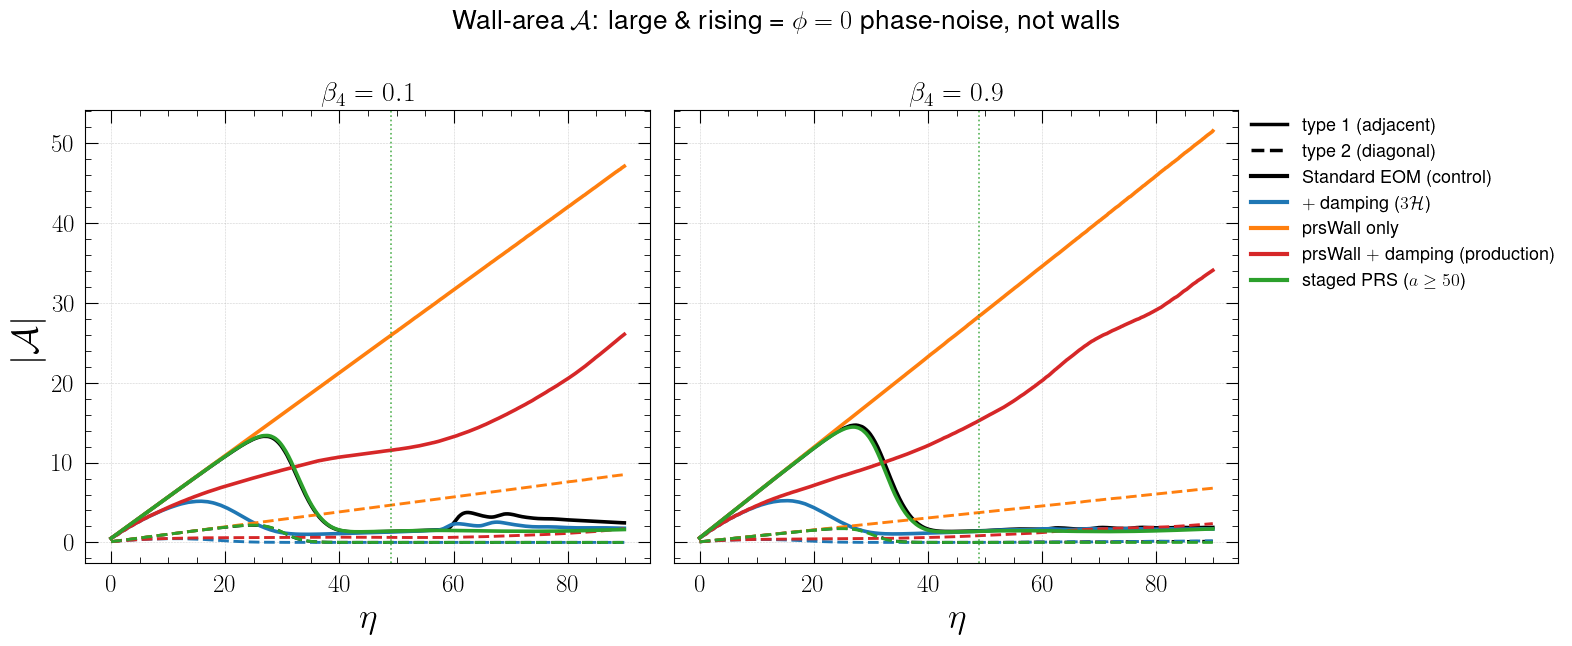

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6.5), sharey=True)
for ax, b in zip(axes, BETA4_VALS):
    for vk in VKEYS:
        d = runs[b][vk]
        if d["energies"] is None: continue
        e1, A1 = area_param(d, "scal1")
        e2, A2 = area_param(d, "scal2")
        ax.plot(e1, np.abs(A1), color=d["color"], ls="-",  lw=d["lw"])
        ax.plot(e2, np.abs(A2), color=d["color"], ls="--", lw=d["lw"]*0.8)
    mark_switch(ax, b)
    # ax.set_yscale("log")
    paper_ax(ax, ylabel=r"$|\mathcal{A}|$" if b == BETA4_VALS[0] else "", title=rf"$\beta_4 = {b}$")
type_h = [Line2D([0],[0], color="k", lw=2.5, ls="-",  label="type 1 (adjacent)"),
          Line2D([0],[0], color="k", lw=2.5, ls="--", label="type 2 (diagonal)")]
axes[1].legend(handles=type_h + variant_handles(), fontsize=13, frameon=False,
               loc="upper left", bbox_to_anchor=(1.01, 1), borderaxespad=0)
fig.suptitle(r"Wall-area $\mathcal{A}$: large \& rising = $\phi=0$ phase-noise, not walls",
             fontsize=19, y=1.0)
plt.tight_layout()
plt.savefig("Z4_prs_diag_area.pdf", bbox_inches="tight")
plt.show()

## 4 &middot; Gradient \& kinetic energy — homogeneous vs. structured

Walls are gradient energy. A frozen homogeneous $\phi=0$ field has $E_g, E_k$ crashing toward
machine zero; a broken network sustains them. (Field-0 components shown; log scale.)

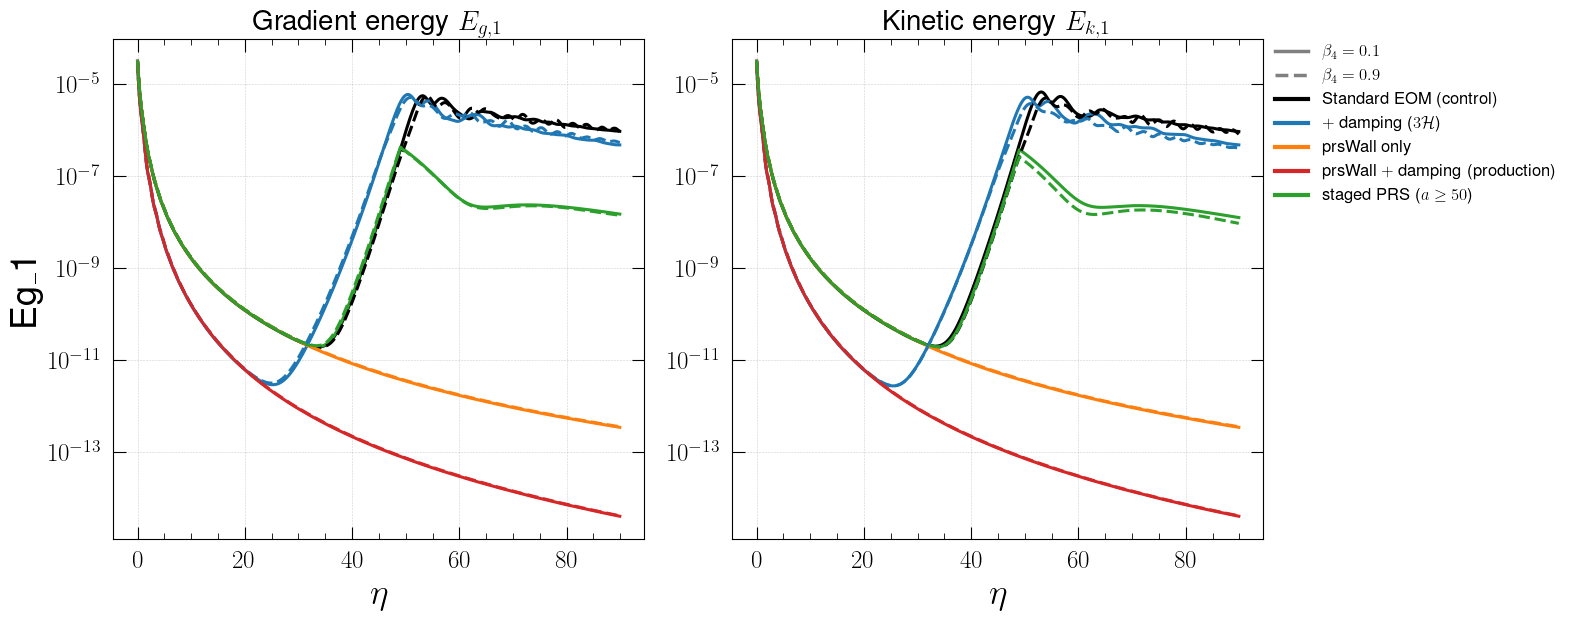

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6.5))
for col, (key, ttl) in enumerate([("Eg_1", r"Gradient energy $E_{g,1}$"),
                                   ("Ek_1", r"Kinetic energy $E_{k,1}$")]):
    ax = axes[col]
    for b in BETA4_VALS:
        for vk in VKEYS:
            d = runs[b][vk]; en = d["energies"]
            if en is None: continue
            # solid for beta4=0.1, dashed for beta4=0.9, coloured by variant
            ls = "-" if b == BETA4_VALS[0] else "--"
            ax.plot(en["eta"], np.abs(en[key]) + 1e-30, color=d["color"], ls=ls, lw=2.2)
    ax.set_yscale("log")
    paper_ax(ax, ylabel=key if col == 0 else "", title=ttl)
beta_h = [Line2D([0],[0], color="grey", lw=2.5, ls="-",  label=r"$\beta_4=0.1$"),
          Line2D([0],[0], color="grey", lw=2.5, ls="--", label=r"$\beta_4=0.9$")]
axes[1].legend(handles=beta_h + variant_handles(), fontsize=12, frameon=False,
               loc="upper left", bbox_to_anchor=(1.01, 1), borderaxespad=0)
plt.tight_layout()
plt.savefig("Z4_prs_diag_gradient_kinetic.pdf", bbox_inches="tight")
plt.show()

## 5 &middot; Why staged PRS (v4stag) can't win — the resolution tension

The box is sized for **2 grid points across the thinnest wall at $a=1$**. Under the *standard*
EOM the comoving wall width shrinks as $\bar\delta/a$, so by the time breaking completes
($a\sim50$) the wall is already **far sub-grid**. Switching PRS on at $a=50$ therefore freezes a
wall that the lattice can no longer resolve — which is exactly why v4stag tracks v0std up to the
switch, then peaks lower and *decays* instead of locking in a network.

In [10]:
print(f"{'beta4':>6s} {'dx':>7s} {'d_min':>6s} {'pts/wall a=1':>13s} "
      f"{'pts/wall a=50':>14s} {'pts/wall a_end':>15s} {'eta_break(v0std)':>17s}")
print("-" * 84)
for b in BETA4_VALS:
    d = runs[b]["v0std"]; dx = d["dx"]; dmin = delta_min(b)
    a_end = d["scale_factor"]["a"][-1]
    p1   = dmin / dx
    p50  = dmin / (PRS_START_A * dx)
    pend = dmin / (a_end * dx)
    ebr  = eta_break(d["energies"])
    print(f"{b:6.2f} {dx:7.4f} {dmin:6.3f} {p1:13.2f} {p50:14.3f} {pend:15.4f} "
          f"{(f'{ebr:.1f}' if ebr is not None else '--'):>17s}")
print("\n=> at the a=50 switch the wall is ~0.04 grid points wide: irrecoverably sub-grid.")

 beta4      dx  d_min  pts/wall a=1  pts/wall a=50  pts/wall a_end  eta_break(v0std)
------------------------------------------------------------------------------------
  0.10  0.7000  1.400          2.00          0.040          0.0220              52.7
  0.90  0.5435  1.087          2.00          0.040          0.0220              53.7

=> at the a=50 switch the wall is ~0.04 grid points wide: irrecoverably sub-grid.


## Diagnosis

| variant | breaks? | $\mathrm{rms}\,\phi_{\rm end}$ | $E_{V_1,\rm end}$ | reading |
|---------|:-------:|:----:|:----:|---------|
| v0std   | **yes** | $\sim0.6$–$0.7$ | $-V_0$ | control: standard EOM breaks at $\eta\approx52$ |
| v1damp  | **yes** | $\sim0.6$ | $-V_0$ | extra Hubble drag only delays slightly — *not* the cause |
| v2wall  | **no**  | $\sim0$ (noise) | $+V_0$ | `prsWall` alone freezes the field |
| v3both  | **no**  | $\sim0$ (noise) | $+V_0$ | production config — frozen; rising $\mathcal{A}$ is phase-noise |
| v4stag  | partial | $\sim0.3$ (decaying) | $+1.6\times10^{-5}$ | breaks, then the $a=50$ switch freezes a sub-grid wall |

**Conclusion.** `prsWall` (dropping the $a^2$ on $V'$) is the culprit: it removes the
$a^2\mu^2$ tachyonic amplification, so a field starting at $\phi=0$ **never breaks the
symmetry**. The extra $3\mathcal{H}$ damping (v1damp) is innocent. Staging the switch (v4stag)
doesn't rescue it, because breaking completes only at $a\sim50$ where the comoving wall is
already $\ll1$ grid point — the staged PRS freezes a wall the lattice cannot resolve.

**Next.** PRS is valid only for maintaining an *already-formed* network. Generate the production
config (user chose "both, staged") only if a way to form walls early exists; otherwise the clean
fix is a **vacuum-manifold random-phase initial condition** (`prsWall=true` from $t_0$, walls
present at $a=1$). Also: gate $\mathcal{A}$ in `Z4_prs_scan_analysis.ipynb` — only trust it once
$E_{V_1}<0$ (or $\mathrm{rms}\,\phi>0.5\,v$); otherwise it reads noise.